In [57]:
# MAVEN data exploration

# type is STS 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

#print(os.getcwd())

# You will have to input your own data folder path
folder_path = "../../final-project-data/MAVEN"

print(os.listdir(folder_path))

sample = os.path.join(folder_path, "mvn_mag_l2_2017246ss1s_20170903_v01_r01.sts")
#with open(sample, 'r') as f:
#    for i, line in enumerate(f):
#        print(line, end='')
#        if i > 30:  # just print first 30 lines
#           break

#with open(sample, 'r') as f:
#    for i, line in enumerate(f):
#        print(f"{i}: {line}", end='')
#        if i > 145:
#            break

def read_maven_mag(filepath):
    df = pd.read_csv(
        filepath,
        skiprows=145,
        sep='\s+',
        header=None
    )
    print(df.shape)
    print(df.head())
    return df

df = read_maven_mag(sample)


def read_maven_mag(filepath):
    df = pd.read_csv(
        filepath,
        skiprows=145,
        sep=r'\s+',
        header=None,
        names=[
            'year', 'doy', 'hour', 'min', 'sec', 'msec',
            'dday',                                          
            'Bx', 'By', 'Bz',                             
            'Bflag',                                       
            'x', 'y', 'z',                               
            'posflag',                                    
            'dBx', 'dBy', 'dBz'                         
        ]
    )


    df['datetime'] = pd.to_datetime(df['year'], format='%Y') + \
                    pd.to_timedelta(df['doy'] - 1, unit='D') + \
                    pd.to_timedelta(df['hour'], unit='h') + \
                    pd.to_timedelta(df['min'], unit='m') + \
                    pd.to_timedelta(df['sec'], unit='s') + \
                    pd.to_timedelta(df['msec'], unit='ms')


    return df



files_1s = sorted(glob.glob(os.path.join(folder_path, "*ss1s*.sts")))
print(f"Reading {len(files_1s)} files...")

df_all = pd.concat([read_maven_mag(f) for f in files_1s], ignore_index=True)
df_all = df_all.sort_values('datetime').reset_index(drop=True)
df_all['Bmag'] = np.sqrt(df_all['Bx']**2 + df_all['By']**2 + df_all['Bz']**2)

print(f"Total rows: {len(df_all)}")
print(df_all[['datetime', 'Bx', 'By', 'Bz', 'x', 'y', 'z']].head())



<>:34: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:34: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_2816/692306042.py:34: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sep='\s+',


['acknowledgement.txt', 'info.txt', 'MAVEN', 'mvn_mag_l2_2017246ss1s_20170903_v01_r01.sts', 'mvn_mag_l2_2017246ss_20170903_v01_r01.sts', 'mvn_mag_l2_2017247ss1s_20170904_v01_r01.sts', 'mvn_mag_l2_2017247ss_20170904_v01_r01.sts', 'mvn_mag_l2_2017248ss1s_20170905_v01_r01.sts', 'mvn_mag_l2_2017248ss_20170905_v01_r01.sts', 'mvn_mag_l2_2017249ss1s_20170906_v01_r01.sts', 'mvn_mag_l2_2017249ss_20170906_v01_r01.sts', 'mvn_mag_l2_2017250ss1s_20170907_v01_r01.sts', 'mvn_mag_l2_2017250ss_20170907_v01_r01.sts', 'mvn_mag_l2_2017251ss1s_20170908_v01_r01.sts', 'mvn_mag_l2_2017251ss_20170908_v01_r01.sts', 'mvn_mag_l2_2017252ss1s_20170909_v01_r01.sts', 'mvn_mag_l2_2017252ss_20170909_v01_r01.sts', 'mvn_mag_l2_2017253ss1s_20170910_v01_r01.sts', 'mvn_mag_l2_2017253ss_20170910_v01_r01.sts', 'mvn_mag_l2_2017254ss1s_20170911_v01_r01.sts', 'mvn_mag_l2_2017254ss_20170911_v01_r01.sts', 'mvn_mag_l2_2017255ss1s_20170912_v01_r01.sts', 'mvn_mag_l2_2017255ss_20170912_v01_r01.sts', 'mvn_mag_l2_2017256ss1s_20170913_v0

In [67]:
max_idx = df_all["Bmag"].idxmax()
t_max = pd.Series(df_all.loc[max_idx, 'datetime']).iloc[0]
b_max = pd.Series(df_all.loc[max_idx, 'Bmag']).iloc[0]
date_str = t_max.strftime('%Y-%m-%d %H:%M:%S')
print(t_max)

2017-09-13 07:55:51.489000


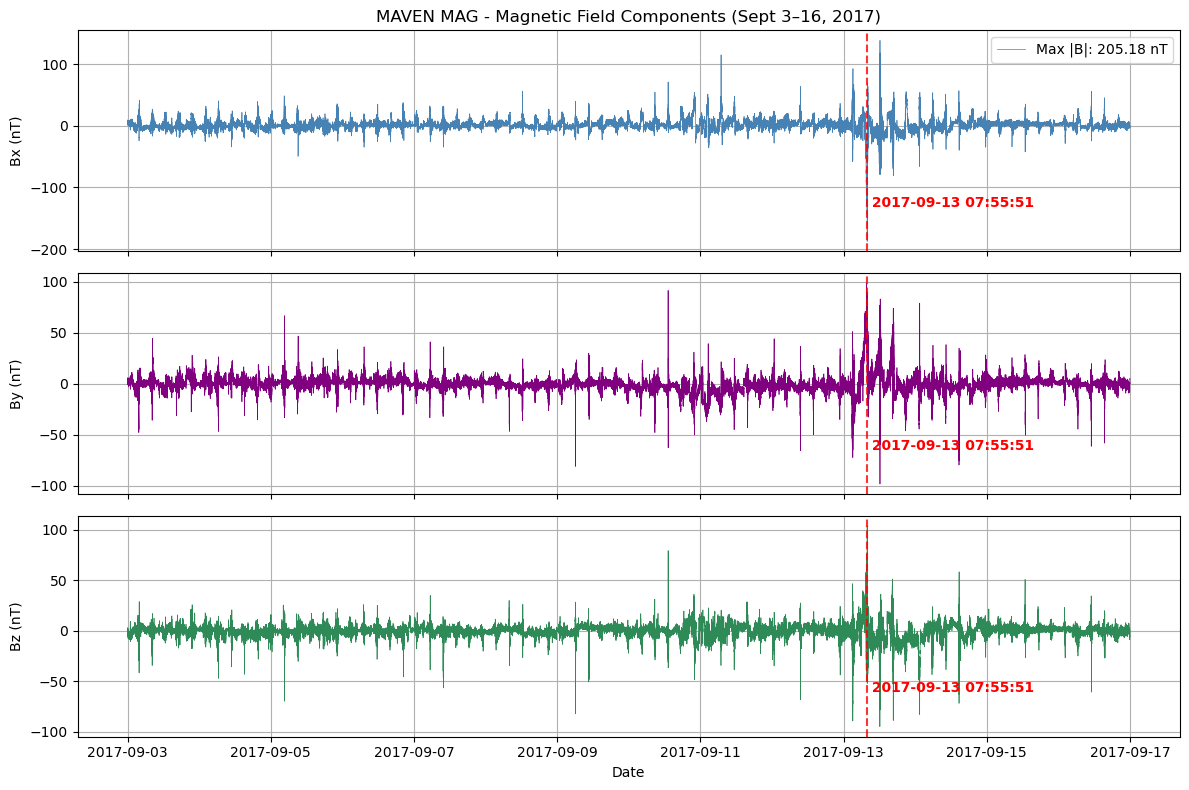

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, col, color in zip(axes, ['Bx', 'By', 'Bz'], ['steelblue', 'purple', 'seagreen']):
    ax.plot(df_all['datetime'], df_all[col], lw=0.5, color=color)
    ax.set_ylabel(f'{col} (nT)')



    ax.axvline(x=t_max, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.text(x=t_max, 
            y=0.25,             
            s=f' {date_str}',   
            color='red', 
            fontweight='bold',
            transform=ax.get_xaxis_transform(), 
            verticalalignment='top',
            horizontalalignment='left')
    
    ax.grid(True)
axes[0].set_title('MAVEN MAG - Magnetic Field Components (Sept 3–16, 2017)')
axes[-1].set_xlabel('Date')
axes[0].legend([ f'Max |B|: {b_max:.2f} nT'], loc='upper right')


plt.tight_layout()
plt.show()




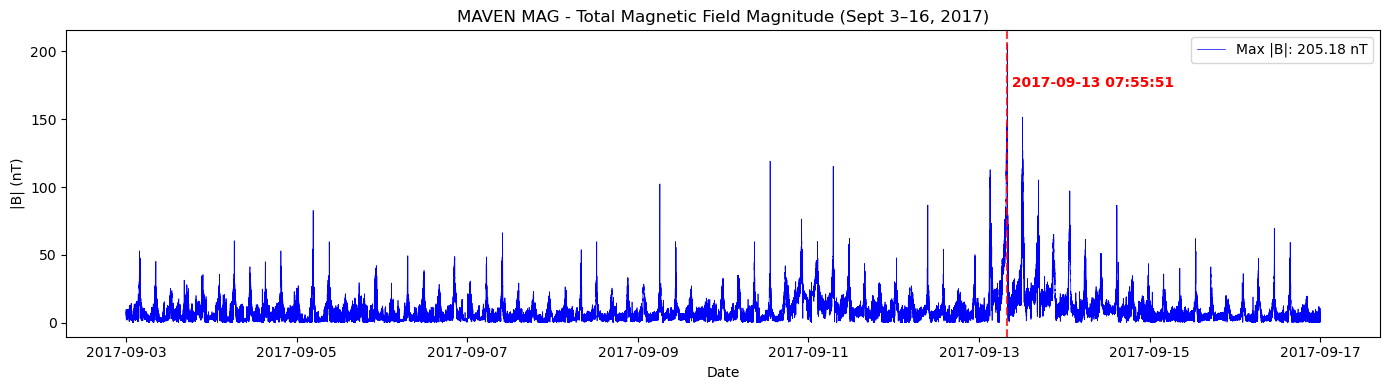

In [60]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_all['datetime'], df_all['Bmag'], lw=0.5, color='blue')
ax.axvline(x=t_max, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(x=t_max, 
        y=0.85,             
        s=f' {date_str}',   
        color='red', 
        fontweight='bold',
        transform=ax.get_xaxis_transform(), 
        verticalalignment='top',
        horizontalalignment='left')
ax.set_ylabel('|B| (nT)')
ax.legend([ f'Max |B|: {b_max:.2f} nT'], loc='upper right')
ax.set_xlabel('Date')
ax.set_title('MAVEN MAG - Total Magnetic Field Magnitude (Sept 3–16, 2017)')
plt.tight_layout()
plt.show()

In [61]:
print(f"Files loaded: {len(files_1s)}")
print(f"Total rows: {len(df_all)}")
print(f"Date range: {df_all['datetime'].min()} to {df_all['datetime'].max()}")

Files loaded: 14
Total rows: 1209599
Date range: 2017-09-03 00:00:02.847000 to 2017-09-17 00:00:00.502000
